In [ ]:
import sys
import json
import imageio
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from skimage.filters import gaussian

sys.path.append("scripts/utils/")
from Microscopes import Tomocube
from file_operations import load_stack

In [38]:
data_path = "../../../../hdd_data/silja/Monolayers/"
dataset   = "MDCK_20250904_B1-1"
_3DQPI    = Tomocube()

config = json.load(open(f"configs/{dataset}.json"))
n_stack  = load_stack(f"{data_path}ri_fields/raw/{dataset}", config, param="n")
h_stack  = load_stack(f"{data_path}height_fields/raw/{dataset}", config, param="h")

In [ ]:
# Apply Gaussian blur
blurred_hstack = []
for im in h_stack:
    blurred_hstack.append(gaussian(im, sigma=5))

In [43]:
# Fit 2nd order polynomial to mean intensity
def polynomial(t, a, b, c):
    return a*t**2 + b*t + c

frames = np.arange(len(h_stack))
param, popt = curve_fit(polynomial, frames, np.mean(blurred_hstack, axis=(1,2)), p0=[0, 1/40, 7.9])

h_mean = np.mean(blurred_hstack, axis=(1,2))
n_mean = np.mean(n_stack, axis=(1,2))

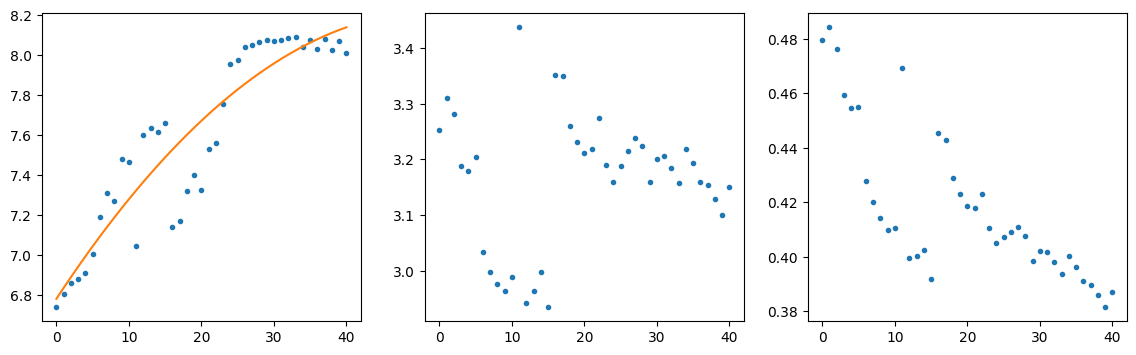

In [ ]:

plt.figure(figsize=(14,3))
plt.subplot(131)
plt.plot(h_mean, '.')
plt.plot(frames, polynomial(frames, *param))

plt.subplot(132)
plt.plot(n_mean, '.')

plt.subplot(133)
plt.plot(n_mean / polynomial(frames, *param), '.')

Text(0.5, 0, 'time (frame)')

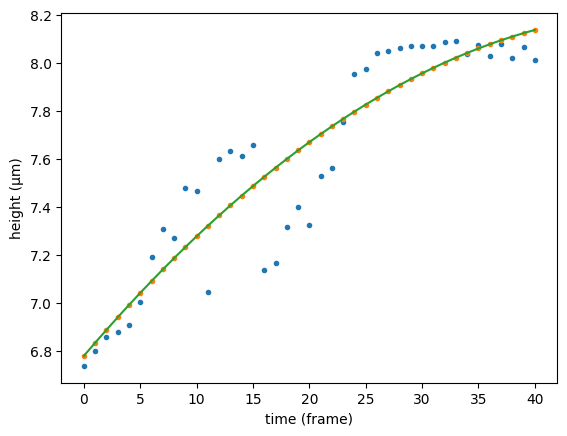

In [ ]:
# rescale data to follow fit
rescaled_hstack = []
averaged_nstack = []

for h_im, n_im, frame in zip(blurred_hstack, n_stack, frames):
    rescaled_hstack.append(h_im * _3DQPI.z_to_um * polynomial(frame, *param)/ np.mean(h_im))
    averaged_nstack.append(n_im / h_im)

plt.figure(figsize=(8,3))
plt.subplot(121)
plt.plot(frames, h_mean, '.')
plt.plot(frames, np.mean(rescaled_hstack, axis=(1,2)), '.')
plt.plot(frames, polynomial(frames,  *param))
plt.ylabel("height (µm)")
plt.xlabel("time (frame)")

plt.subplot(121)
plt.plot(frames, n_mean / h_mean)
plt.plot(frames, np.mean(averaged_nstack, axis=(1,2)), '.')

In [ ]:
# save data
for i in range(len(rescaled_hstack)):
    hframe = rescaled_hstack[i] / _3DQPI.h_to_um
    nframe = averaged_nstack[i] / _3DQPI.ri_conversion 

    imageio.imwrite(f"{data_path}height_fields/raw/{dataset}/MDCK-li_height_{i}.tiff",       np.array(hframe, dtype=np.uint16))
    imageio.imwrite(f"{data_path}ri_fields/raw/{dataset}/MDCK-li_refractive_index_{i}.tiff", np.array(nframe, dtype=np.uint16))
